# Introduction

In this notebook I will automate the process of creation the database I will use to investigate and define my target. The database on the NBA from 2000-2001 to 2024-2025.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

## Handling the columns name

In many columns either the name is not the good name, either it creates duplicates even though data are different e.g. *PTS Totals and PTS on average*.

In [4]:
#Type of games
type_game = {
    #"Playoff" : "PO ",
    "Regular Season" : ""
}

In [8]:
home = r"C:\Users\Utilisateur\Desktop\Master ULB\Mémoire\Database\NBA\Stats 2000 to 2024"
for key, value in type_game.items():
    for year in range(1, 26):
        if year < 10:
            date = f"200{str(year-1)}-200{str(year)}"
        if year == 10:
            date = f"200{str(year-1)}-20{str(year)}"
        if year > 10:
            date = f"20{str(year-1)}-20{str(year)}"

        #Import the correct data
        path = home + rf"\{date}\{key}\NBA {value}{date} Avg.xlsx"
        avg = pd.read_excel(path)
        path2 = home + rf"\{date}\{key}\NBA {value}{date} PBP.xlsx"
        pbp = pd.read_excel(path2, skiprows=1)
        path3 = home + rf"\{date}\{key}\NBA {value}{date} Advanced.xlsx"
        advanced = pd.read_excel(path3)
        path4 = home + rf"\{date}\{key}\NBA {value}{date} Shooting.xlsx"
        shooting = pd.read_excel(path4, skiprows=1)
        path5 = home + rf"\{date}\{key}\NBA {value}{date} Adj Shooting.xlsx"
        adj_shoot = pd.read_excel(path5, skiprows=1)
        path6 = home + rf"\{date}\{key}\NBA {value}{date} Totals.xlsx"
        totals = pd.read_excel(path6)
        path7 = home + rf"\{date}\{key}\NBA {value}{date} Per 36.xlsx"
        per_36 = pd.read_excel(path7)

        #To be done on one season statistics
        #Change the columns name -9999 to player additional 
        dfs = [advanced, totals, per_36, shooting, adj_shoot, pbp]
        for df in dfs:
            if -9999 in df.columns:
                df.rename(columns={-9999: 'Player-additional'}, inplace=True)

        #Change the redundants columns names to unique columns name
        dfs = [totals, avg, per_36, advanced, pbp, shooting, adj_shoot]

        dict_of_change = { ##Create a dictionnary taking as key the number of iteration and as value the name of the df
            0 : "totals",
            1 : "avg",
            2 : "per_36",
            3 : "advanced",
            4 : "pbp",
            5 : "shooting",
            6 : "adj_shoot"
        }

        print(date)
        base =  totals.columns.to_list()
        base.remove('Player-additional')
        base.remove('Team')#Remove the UID from the base
        for index, i in enumerate(dfs[1:]):
            index = index + 1
            for col in i.columns:
                if col in base:
                    i.rename(columns={col : col + f"_{dict_of_change[index]}"}, inplace=True)

        #Merge the 7 dataframes together
        merged_df = avg.copy()
        for i in dfs:
            merged_df = pd.merge(merged_df, i, on=['Player-additional', 'Team'])

        #Add a column the identify the season
        merged_df['season'] = year

        #Concat the dfs year by year
        if key == 'Regular Season':
            if year > 1:
                final_df = pd.concat([final_df, merged_df])
            else:
                final_df = merged_df.copy()
        else:
            if year > 1:
                final_df_po = pd.concat([final_df, merged_df])
            else:
                final_df_po = merged_df.copy()

2000-2001
2001-2002
2002-2003
2003-2004
2004-2005
2005-2006
2006-2007
2007-2008
2008-2009
2009-2010
2010-2011
2011-2012
2012-2013
2013-2014
2014-2015
2015-2016
2016-2017
2017-2018
2018-2019
2019-2020
2020-2021
2021-2022
2022-2023
2023-2024
2024-2025


# Exporting the dfs

In [10]:
final_df.to_excel('Regular Season.xlsx', index=False)
#final_df_po.to_excel('Playoff.xlsx', index=False)

# Scrapping

In [2]:
from bs4 import BeautifulSoup
import requests

## Injuries

In [ ]:
for i in range(15, 25):
    
    #Fetch the HTML content of the page
    url = f'https://www.spotrac.com/nba/injured/_/year/20{str(i)}/view/player'  # Replace with the URL of the site containing the table
    response = requests.get(url)

    #Check if the request was successful
    if response.status_code == 200:
        html_content = response.content
    else:
        print(f"Failed to retrieve the page. Status code: {response.status_code}")
        exit()

    #Parse the HTML content using BeautifulSoup
    soup = BeautifulSoup(html_content, 'html.parser')

    #Locate the table in the HTML
    table = soup.find('table') 

    #Extract the table headers (if any)
    headers = []
    header_row = table.find('thead').find('tr') if table.find('thead') else table.find('tr')
    for th in header_row.find_all('th'):
        headers.append(th.text.strip())

    #Extract the table rows
    rows = []
    for row in table.find('tbody').find_all('tr') if table.find('tbody') else table.find_all('tr'):
        cells = row.find_all('td')
        if len(cells) > 0:  #Ensure the row contains data
            rows.append([cell.text.strip() for cell in cells])

    #Convert the data into a pandas DataFrame
    df = pd.DataFrame(rows, columns=headers)

    #Save the DataFrame to a CSV file
    df.to_excel(f'NBA Injury 20{str(i)}.xlsx', index=False)

## Rookie Scale

In [ ]:
for i in range(0, 25):
    if i < 10:
        #Fetch the HTML content of the page
        url = f'https://www.spotrac.com/nba/cba/rookie-scale/_/year/200{str(i)}'  
        response = requests.get(url)
    else:
        url = f'https://www.spotrac.com/nba/cba/rookie-scale/_/year/20{str(i)}' 
        response = requests.get(url)

    #Check if the request was successful
    if response.status_code == 200:
        html_content = response.content
    else:
        print(f"Failed to retrieve the page. Status code: {response.status_code}")
        exit()

    #Parse the HTML content using BeautifulSoup
    soup = BeautifulSoup(html_content, 'html.parser')

    #Locate the table in the HTML
    table = soup.find('table') 

    #Extract the table headers (if any)
    headers = []
    header_row = table.find('thead').find('tr') if table.find('thead') else table.find('tr')
    for th in header_row.find_all('th'):
        headers.append(th.text.strip())

    #Extract the table rows
    rows = []
    for row in table.find('tbody').find_all('tr') if table.find('tbody') else table.find_all('tr'):
        cells = row.find_all('td')
        if len(cells) > 0:  #Ensure the row contains data
            rows.append([cell.text.strip() for cell in cells])

    #Convert the data into a pandas DataFrame
    df = pd.DataFrame(rows, columns=headers)

    #Optionally, save the DataFrame to a CSV file
    if i < 10:
        df.to_csv(f'NBA Rookie Scales 200{str(i)}.csv', index=False)
    else:
        df.to_csv(f'NBA Rookie Scales 20{str(i)}.csv', index=False)

## Draft

In [ ]:
for tho in range(25, 26):
    if tho < 10:
        #Fetch the HTML content of the page
        url = f'https://www.basketball-reference.com/draft/NBA_200{str(tho)}.html'
        response = requests.get(url)
    else:
        url = f'https://www.basketball-reference.com/draft/NBA_20{str(tho)}.html' 
        response = requests.get(url)

    #Check if the request was successful
    if response.status_code == 200:
        html_content = response.content
    else:
        print(f"Failed to retrieve the page. Status code: {response.status_code}")
        exit()

    #Parse the HTML content using BeautifulSoup
    soup = BeautifulSoup(html_content, 'html.parser')

    #Locate the table in the HTML
    table = soup.find('table')

    if not table:
        print("No table found on the page.")
        exit()

    #Extract the subheaders (most granular level of headers)
    headers = []
    header_rows = table.find_all('tr')  # Find all rows in the header

    for row in header_rows:
        cells = row.find_all(['th', 'td'])
        if cells:
            headers = ['Pk',	'Tm',	'Player',	'College',	'Yrs',	'G',	
                       'MP',	'PTS',	'TRB',	'AST',	'FG%',	'3P%',	'FT%',	'MP',
                    	'PTS',	'TRB',	'AST',	'WS',	'WS/48',	'BPM',	'VORP']
            break  

    #If no headers found, use default column names
    if not headers:
        print("No subheaders found. Using default column names.")
        headers = [f"Column_{i+1}" for i in range(len(table.find('tr').find_all('td')))]

    #Extract the table rows
    rows = []
    for row in table.find('tbody').find_all('tr') if table.find('tbody') else table.find_all('tr'):
        cells = row.find_all('td')
        if len(cells) > 0:
            rows.append([cell.text.strip() for cell in cells])

    #Debugging - Check the number of columns in headers and rows
    print(f"Number of subheaders: {len(headers)}")
    print(f"Number of columns in first row: {len(rows[0]) if rows else 0}")

    #Ensure all rows have the same number of columns
    if rows:
        num_columns = len(rows[0])
        for i, row in enumerate(rows):
            if len(row) != num_columns:
                print(f"Warning: Row {i+1} has {len(row)} columns (expected {num_columns}).")

    #Convert the data into a pandas DataFrame
    try:
        df = pd.DataFrame(rows, columns=headers)
        print(df)
    except ValueError as e:
        print(f"Error creating DataFrame: {e}")

    if tho < 10:
        df.to_csv(f'NBA Draft Picks 200{str(tho)}.csv', index=False)
    else:
        df.to_csv(f'NBA Draft Picks 20{str(tho)}.csv', index=False)

Failed to retrieve the page. Status code: 404


NameError: name 'html_content' is not defined

: 

## Fines & Suspensions

In [ ]:
for i in range(11, 25):
    
    #Fetch the HTML content of the page
    url = f'https://www.spotrac.com/nba/fines-suspensions/_/year/20{str(i)}' 
    response = requests.get(url)

    #Check if the request was successful
    if response.status_code == 200:
        html_content = response.content
    else:
        print(f"Failed to retrieve the page. Status code: {response.status_code}")
        exit()

    #Parse the HTML content using BeautifulSoup
    soup = BeautifulSoup(html_content, 'html.parser')

    #Locate the table in the HTML
    table = soup.find('table') 

    #Extract the table headers
    headers = []
    header_row = table.find('thead').find('tr') if table.find('thead') else table.find('tr')
    for th in header_row.find_all('th'):
        headers.append(th.text.strip())

    #Extract the table rows
    rows = []
    for row in table.find('tbody').find_all('tr') if table.find('tbody') else table.find_all('tr'):
        cells = row.find_all('td')
        if len(cells) > 0:  #Ensure the row contains data
            rows.append([cell.text.strip() for cell in cells])

    #Convert the data into a pandas DataFrame
    df = pd.DataFrame(rows, columns=headers)

    df.to_csv(f'NBA Fines & Suspensions 20{str(i)}.csv', index=False)

## Team Statistics

In [ ]:
home = r"C:\Users\Utilisateur\Desktop\Master ULB\Mémoire\Database\NBA\Stats"
path = home + r"\2023-2024\Regular Season\NBA 2023-2024 Avg.xlsx"
df_for_team = pd.read_excel(path)


#Put all the teams in a list
teams = df_for_team['Team'].unique().tolist()
del teams[-2:]
teams.remove('2TM')

#Put all the criteria in a list
stats = {
    'stats_per_game_totals' : 'Avg',
    'opp_stats_per_game_totals' : 'Opps',
    'stats_per_game_yr_yr' : 'Year-Over-Year',
    'opp_stats_per_game_yr_yr' : 'YoY Opp',
    'stats_per_game_ranks' : 'Ranking',
    'opp_stats_per_game_ranks' : 'Opp Ranking'
    }

In [ ]:
for team in teams:
    for stat, key in stats.items():
        #Fetch the HTML content of the page
        url = f'https://www.basketball-reference.com/teams/{team}/{stat}.html'  # Replace with the URL of the site containing the table
        response = requests.get(url)
        
        #Check if the request was successful
        if response.status_code == 200:
            html_content = response.content
        else:
            print(f"Failed to retrieve the page. Status code: {response.status_code}")
            exit()

        #Parse the HTML content using BeautifulSoup
        soup = BeautifulSoup(html_content, 'html.parser')

        #Locate the table in the HTML
        table = soup.find('table')

        if not table:
            print("No table found on the page.")
            exit()

        #Extract the subheaders (most granular level of headers)
        headers = []
        header_rows = table.find_all('tr') 

    
        for row in header_rows:
            cells = row.find_all(['th', 'td'])
            if cells:
                headers = ['Pk',	'Tm',	'Player',	'College',	'Yrs',	'G',	
                        'MP',	'PTS',	'TRB',	'AST',	'FG%',	'3P%',	'FT%',	'MP',
                            'PTS',	'TRB',	'AST',	'WS',	'WS/48',	'BPM',	'VORP']
                break  
        #If no headers are found, use default column names
        if not headers:
            print("No subheaders found. Using default column names.")
            headers = [f"Column_{i+1}" for i in range(len(table.find('tr').find_all('td')))]

        #Extract the table rows
        rows = []
        for row in table.find('tbody').find_all('tr') if table.find('tbody') else table.find_all('tr'):
            cells = row.find_all('td')
            if len(cells) > 0:
                rows.append([cell.text.strip() for cell in cells])

        #Debugging - Check the number of columns in headers and rows
        print(f"Number of subheaders: {len(headers)}")
        print(f"Number of columns in first row: {len(rows[0]) if rows else 0}")

        #Ensure all rows have the same number of columns
        if rows:
            num_columns = len(rows[0])
            for i, row in enumerate(rows):
                if len(row) != num_columns:
                    print(f"Warning: Row {i+1} has {len(row)} columns (expected {num_columns}).")

        #Convert the data into a pandas DataFrame
        try:
            df = pd.DataFrame(rows, columns=headers)
            print(df)
        except ValueError as e:
            print(f"Error creating DataFrame: {e}")

        df.to_csv(f'NBA {team} {key}.csv', index=False)

Number of subheaders: 21
Number of columns in first row: 33
Error creating DataFrame: 21 columns passed, passed data had 33 columns
Number of subheaders: 21
Number of columns in first row: 29
Error creating DataFrame: 21 columns passed, passed data had 29 columns
Number of subheaders: 21
Number of columns in first row: 30
Error creating DataFrame: 21 columns passed, passed data had 30 columns
Number of subheaders: 21
Number of columns in first row: 26
Error creating DataFrame: 21 columns passed, passed data had 26 columns
Number of subheaders: 21
Number of columns in first row: 33
Error creating DataFrame: 21 columns passed, passed data had 33 columns
Number of subheaders: 21
Number of columns in first row: 29
Error creating DataFrame: 21 columns passed, passed data had 29 columns
Number of subheaders: 21
Number of columns in first row: 33
Error creating DataFrame: 21 columns passed, passed data had 33 columns
Number of subheaders: 21
Number of columns in first row: 29
Error creating D

: 

## Playoff Summary

In [13]:
table = soup.find('table', {'id': 'expanded_standings'})

In [14]:
print(table)

None


In [ ]:
for playoff_year in range (1950, 2025):
    #Fetch the HTML content of the page
    url = f'https://www.basketball-reference.com/playoffs/NBA_{str(playoff_year)}_standings.html'
    response = requests.get(url)
        
    #Check if the request was successful
    if response.status_code == 200:
        html_content = response.content
    else:
        print(f"Failed to retrieve the page. Status code: {response.status_code}")
        exit()

    #Parse the HTML content using BeautifulSoup
    soup = BeautifulSoup(html_content, 'html.parser')

    #Locate the table in the HTML
    table = soup.find('table') 

    #Extract the table rows
    rows = []
    for row in table.find('tbody').find_all('tr') if table.find('tbody') else table.find_all('tr'):
        cells = row.find_all('td')
        if len(cells) > 0:  #Ensure the row contains data
            rows.append([cell.text.strip() for cell in cells])

    #Convert the data into a pandas DataFrame
    df = pd.DataFrame(rows, columns=str(playoff_year))
    
    if playoff_year == 2024:
        df.to_csv(f'NBA All playoff participating team.csv', index=False)
    if playoff_year == 1950:
        working_df = df.copy()
    else:
        working_df = pd.concat(working_df, df, 
                                axis=1)

AttributeError: 'NoneType' object has no attribute 'find'

In [32]:
column.T

AttributeError: 'list' object has no attribute 'T'

In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from bs4 import BeautifulSoup
import time

In [ ]:
for playoff_year in range (1950, 2025):
    #Path for Chrome
    driver = webdriver.Chrome()
    url = f"https://www.basketball-reference.com/playoffs/NBA_{str(playoff_year)}_standings.html"
    driver.get(url)

    #times.sleep to load the page
    time.sleep(2)

    #Get HTML
    html = driver.page_source

    #Parse with BeautifulSoup
    soup = BeautifulSoup(html, "html.parser")

    #Find the table 
    table = soup.find("table", {"id": "expanded_standings"})

    #Check if it contains data
    tbody = table.find("tbody")
    rows = tbody.find_all("tr") if tbody else []

    #rows
    column = []
    for row in rows:
        cells = [cell.text.strip() for cell in row.find_all("td")]
        column.append([cells[0]])

    #Convert the data into a pandas DataFrame
    df = pd.DataFrame(column, columns=[str(playoff_year)])
    #Convert the data into a pandas DataFrame
    
    if playoff_year == 2024:
        working_df.to_csv(f'NBA All playoff participating team.csv', index=False)
    if playoff_year == 1950:
        working_df = df.copy()
    else:
        working_df = pd.concat([working_df, df], 
                                axis=1)

    #Close Selenium
    driver.quit()

In [20]:
for row in table.find("tbody").find_all("tr"):
    cells = row.find_all("td")
    print([cell.text.strip() for cell in cells])


['Minneapolis Lakers', '10-2', '6-0', '4-2', '4-0', '4-2', '2-0', '1-0', '6-0', '4-0', '6-2']
['Syracuse Nationals', '6-5', '5-1', '1-4', '2-4', '4-1', '', '0-1', '2-2', '3-1', '3-4']
['Anderson Packers', '4-4', '3-1', '1-3', '0-2', '', '4-2', '1-2', '3-2', '3-2', '1-2']
['Indianapolis Olympians', '3-3', '3-1', '0-2', '', '', '3-3', '2-1', '0-2', '3-2', '0-1']
['New York Knicks', '3-2', '2-0', '1-2', '', '3-2', '', '1-0', '1-1', '3-1', '0-1']
['Fort Wayne Pistons', '2-2', '1-1', '1-1', '2-2', '', '', '1-0', '0-1', '2-2', '']
['Sheboygan Red Skins', '1-2', '1-0', '0-2', '', '', '1-2', '0-1', '1-0', '1-2', '']
['Tri-Cities Blackhawks', '1-2', '1-0', '0-2', '', '', '1-2', '1-0', '0-2', '1-2', '']
['Chicago Stags', '0-2', '0-1', '0-1', '0-2', '', '', '', '0-1', '0-2', '']
['Philadelphia Warriors', '0-2', '0-1', '0-1', '', '0-2', '', '', '0-1', '0-2', '']
['Rochester Royals', '0-2', '0-1', '0-1', '0-2', '', '', '0-1', '', '0-2', '']
['Washington Capitols', '0-2', '0-1', '0-1', '', '0-2', ''

# Descriptive analysis 

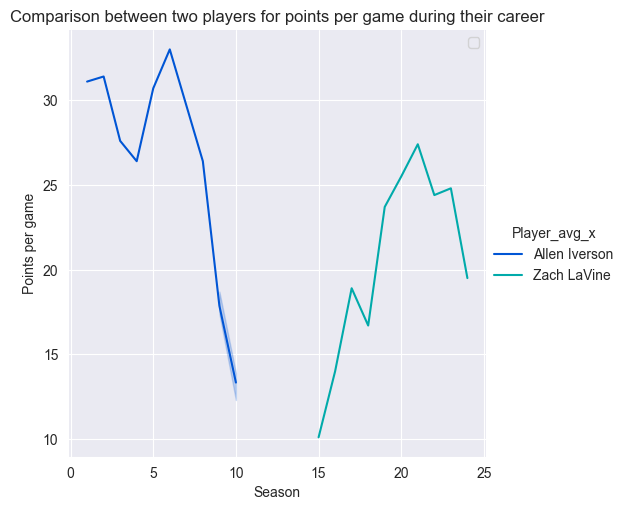

In [306]:
sns.set_style('darkgrid')
sns.relplot(data=final_df[(final_df['Player_avg_x']=='Allen Iverson') &
                       (final_df['PER'].notnull())| 
                       (final_df['Player_avg_x']=='Zach LaVine') &
                       (final_df['PER'].notnull())],
                x='season', 
                y='PTS_avg_x', 
                kind='line',       
                hue='Player_avg_x',
                palette='winter')
plt.title('Comparison between two players for points per game during their career')
plt.legend('')
plt.xlabel('Season')
plt.ylabel('Points per game')
sns.despine();